# Bar Path Model Testing

Predict exercise data using saved model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from os import path
import matplotlib.pyplot as plt
import numpy as np

DATA_COLUMNS = ['AccX', 'AccY', 'AccZ', 'VelX', 'VelY', 'VelZ', 'PosX', 'PosY', 'PosZ', 'Pitch', 'Roll', 'Yaw']

### Load data and config

In [3]:
from utils import load_airtable_data, load_config, load_mongo_data

config = load_config()


In [4]:
from utils import load_airtable_data, load_config, load_mongo_data

#data = load_airtable_data()
data = load_mongo_data()
config = load_config()
data.head()

,_id,Exercise_id,Counter,TimeBetweenSamples,AccX,AccY,AccZ,Pitch,Roll,Yaw,...,DominantAxis,EndPrediction,PredictedRepsCount,Prediction,PreditctedReps,StartPrediction,Weight,Notes,IntensityMetrics,ProcessedData
0,66f8a0facfd19a2dbc3643b7,AD7CECF3-FB0B-4CDD-9C74-35F26FE1C1EA,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[15318, 10, 10, 10, 10, 10, 10, 10, 10, 11, 9,...","[-0.004, -0.049, -0.07, -0.051, -0.004, 0.023,...","[0.046, -0.009, 0.023, -0.019, -0.02, -0.016, ...","[-0.038, -0.014, 0.016, 0.034, 0.026, 0.075, 0...","[0.671, 0.67, 0.669, 0.667, 0.665, 0.664, 0.66...","[-0.017, -0.017, -0.018, -0.017, -0.016, -0.01...","[0.006, 0.007, 0.007, 0.007, 0.006, 0.006, 0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,66f8a1d9cfd19a2dbc3643bf,255F3E86-9C12-4CC0-A503-E65F058E5711,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[195017, 10, 11, 21, 0, 9, 10, 10, 10, 10, 10,...","[-0.226, -0.295, 0.029, 0.275, 0.151, -0.101, ...","[0.095, 0.135, 0.18, 0.186, 0.154, 0.197, 0.18...","[0.019, 0.012, -0.064, -0.194, -0.222, -0.203,...","[0.615, 0.613, 0.612, 0.61, 0.609, 0.608, 0.60...","[-0.182, -0.182, -0.183, -0.185, -0.187, -0.18...","[0.058, 0.059, 0.06, 0.062, 0.064, 0.064, 0.06...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,66f8a2eacfd19a2dbc3643c7,F4B75458-7440-4484-88FD-ADCF4C4F34B4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[244750, 10, 10, 12, 8, 10, 11, 9, 10, 9, 10, ...","[-0.454, -0.14, 0.206, 0.17, 0.146, 0.099, 0.0...","[-0.321, -0.291, -0.243, -0.207, -0.032, 0.17,...","[0.162, 0.112, 0.026, 0.013, -0.063, -0.043, -...","[0.537, 0.534, 0.531, 0.528, 0.526, 0.525, 0.5...","[-0.199, -0.199, -0.199, -0.201, -0.201, -0.20...","[0.055, 0.054, 0.053, 0.052, 0.051, 0.05, 0.04...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,66f8a39ccfd19a2dbc3643cf,98650F9A-F356-4563-9A0E-26FFB73C4D77,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[146117, 10, 10, 10, 10, 10, 12, 9, 10, 10, 10...","[-0.25, 0.027, 0.239, 0.229, 0.186, 0.156, 0.1...","[-0.278, -0.131, 0.076, 0.191, 0.213, 0.18, 0....","[-0.097, -0.134, -0.208, -0.209, -0.182, -0.07...","[0.452, 0.45, 0.449, 0.447, 0.446, 0.445, 0.44...","[-0.018, -0.02, -0.02, -0.02, -0.02, -0.019, -...","[0.004, 0.005, 0.005, 0.005, 0.004, 0.003, 0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,66f8a43ecfd19a2dbc3643d7,CEE08F0F-C418-4B32-88FE-81D6EB5ECC2B,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[122958, 10, 10, 10, 12, 8, 10, 10, 10, 11, 9,...","[0.053, 0.1, 0.188, 0.258, 0.248, 0.13, 0.027,...","[0.116, 0.012, 0.176, 0.226, 0.223, 0.21, 0.12...","[-0.122, -0.151, -0.216, -0.211, -0.13, -0.003...","[0.271, 0.268, 0.268, 0.269, 0.271, 0.273, 0.2...","[0.054, 0.054, 0.052, 0.05, 0.05, 0.05, 0.05, ...","[-0.007, -0.006, -0.004, -0.002, 0.0, 0.001, 0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
exercise_id = '82154D43-907F-4FDB-BF13-F259C72C9E9A'
record = data[data['Exercise_id'] == exercise_id]


## Test the exercise classifier on a random sample

In [6]:
EXERCISE_CLASSIFIER = 'Exercise'

### Load the latest classifier

In [7]:
from utils import load_classifier

exercise_classifier = load_classifier(EXERCISE_CLASSIFIER)


### Predict a random record and plot

Classifier type: Exercise
Prediction: [8]
Actual: DB Goblet Squat


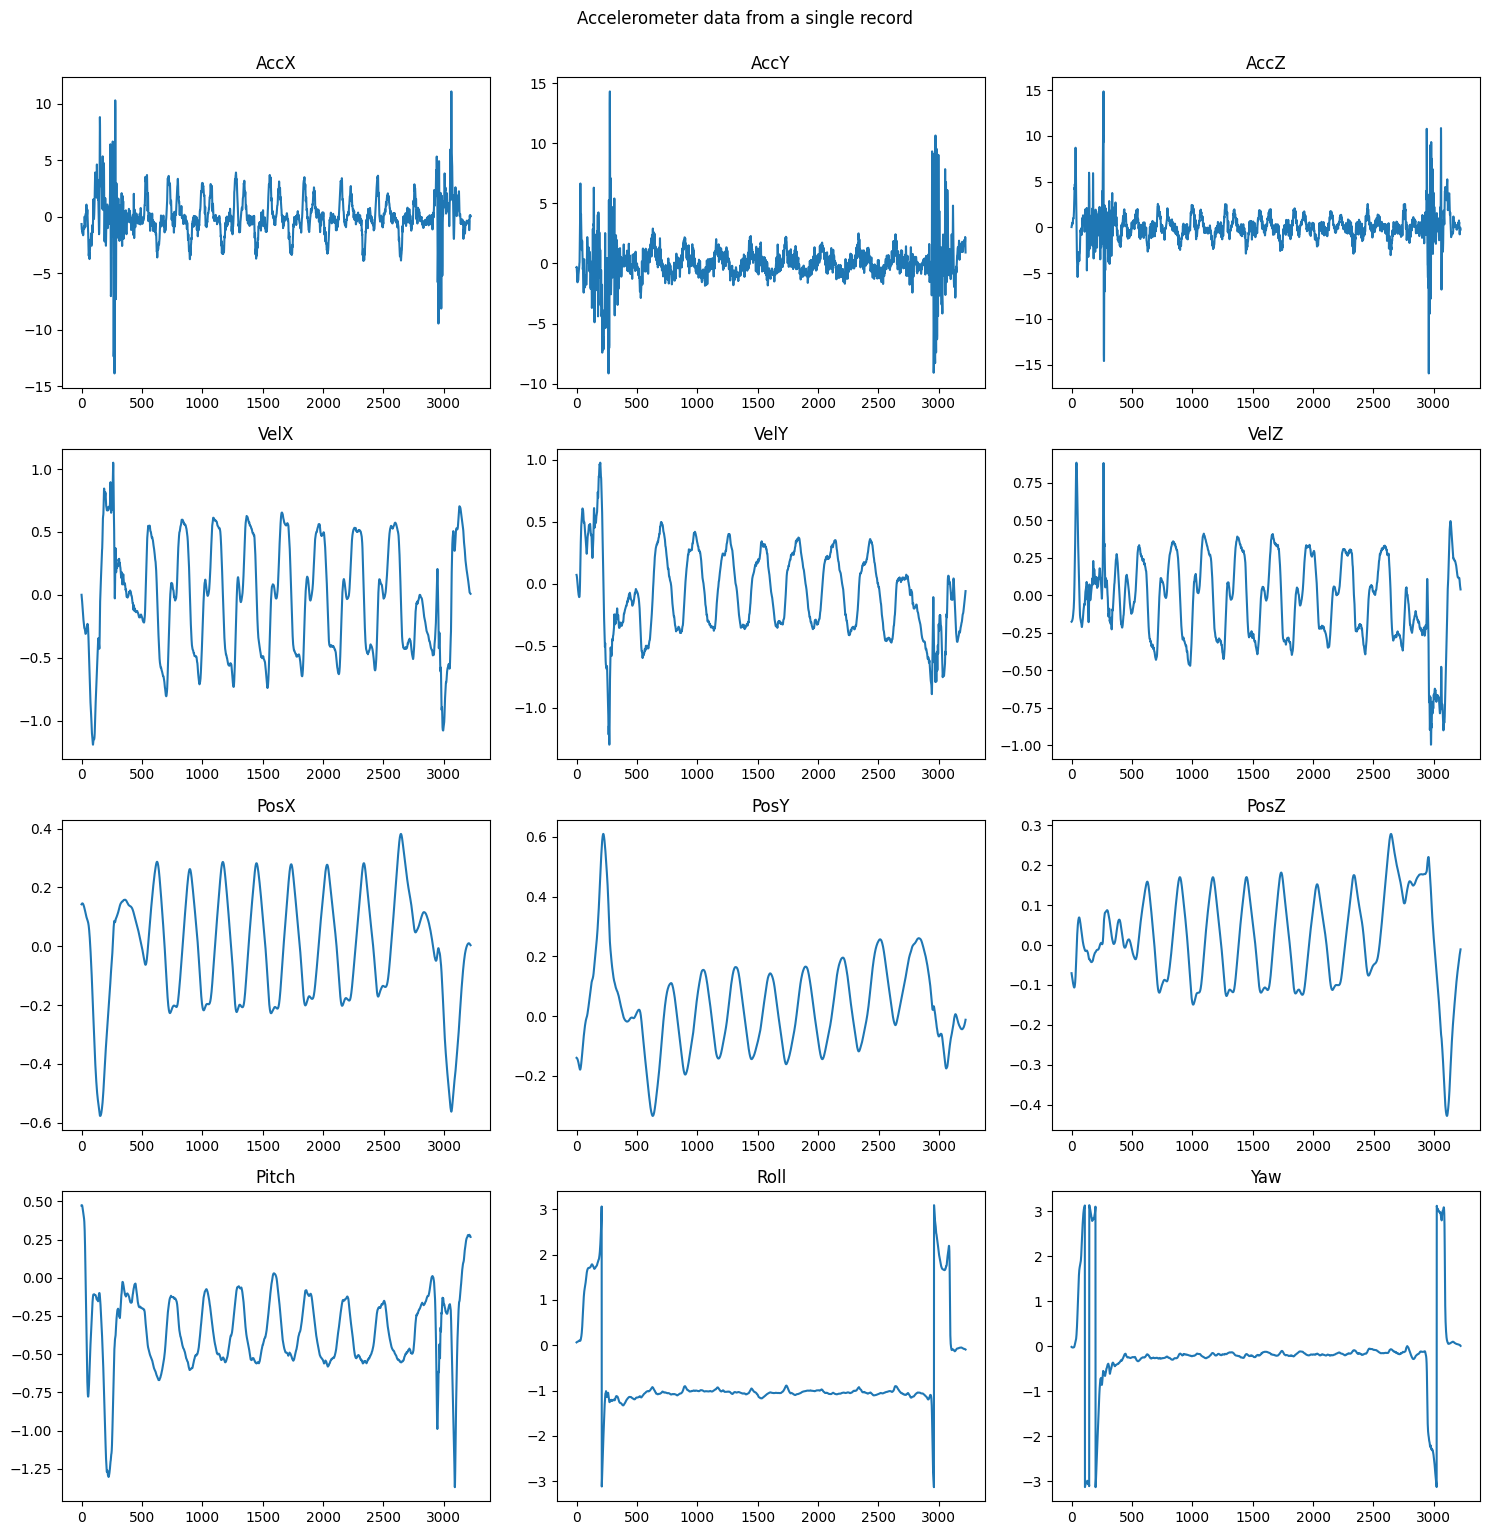

In [8]:

from preprocessing import preprocess_data, extract_features

record = data.sample(1)
record = preprocess_data(record, config['CutoffFreq'], config['SampleRate'])
features = extract_features(record)
prediction = exercise_classifier.predict(features)

print("Classifier type:", EXERCISE_CLASSIFIER)
print(f"Prediction: {prediction}")
print(f"Actual: {record['Exercise'].values[0]}")

fig, axs = plt.subplots(4, 3, figsize=(15, 15))

for i, ax in enumerate(axs.flat):
    plot_data = np.concatenate(record[DATA_COLUMNS[i]].to_numpy())
    ax.plot(plot_data)
    ax.set_title(DATA_COLUMNS[i])

plt.tight_layout()
plt.suptitle('Accelerometer data from a single record', y=1.02)
plt.show()

## Predict the rep start and stop of a random sample

In [9]:
WINDOW_CLASSIFIER = 'Window'

### Load the classifier

In [10]:
window_classifier = load_classifier(WINDOW_CLASSIFIER)

### Predict a random record

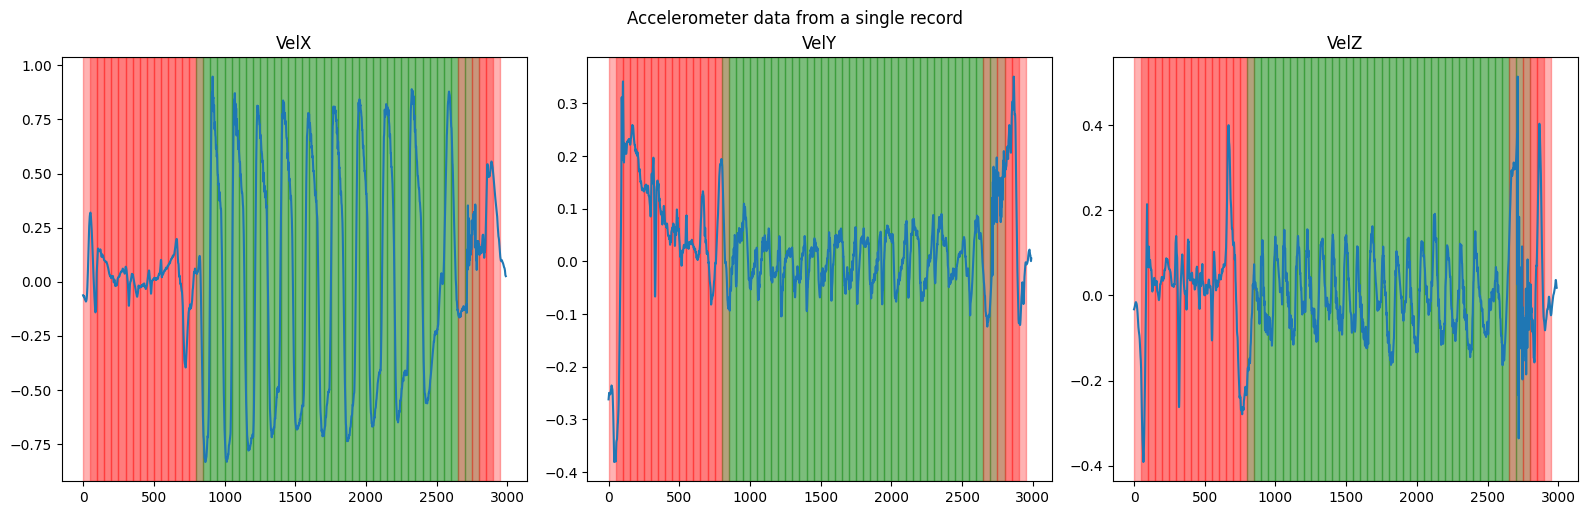

In [39]:
from preprocessing import extract_window_features

exercise_id = '2BF99F85-174F-41C1-B695-6E7684188A79'
record = data[data['Exercise_id'] == exercise_id]
record = record.sample(1)

#record = data.sample(1)
record = preprocess_data(record, config['CutoffFreq'], config['SampleRate'])

window_features = extract_window_features(record, config['WindowLength'], config['WindowStride'])
predictions = window_classifier.predict(window_features)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

VEL_COLUMNS = ['VelX', 'VelY', 'VelZ']
#VEL_COLUMNS = ['Pitch', 'Roll', 'Yaw']


for i, ax in enumerate(axs.flat):
    plot_data = np.concatenate(record[VEL_COLUMNS[i]].to_numpy())
    ax.plot(plot_data)
    ax.set_title(VEL_COLUMNS[i])
    for j in range(len(predictions)):
        ax.axvspan(j * config['WindowStride'], j * config['WindowStride'] + config['WindowLength'], color='green' if predictions[j] == 1 else 'red', alpha=0.3)

plt.tight_layout()
plt.suptitle('Accelerometer data from a single record', y=1.02)
plt.show()

In [24]:
print(predictions)

[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]


### Predict start and end times

In [41]:
from postprocessing import predict_exercise_indices

start_index, end_index = predict_exercise_indices(
    predictions, config['WindowLength'], config['WindowStride'], config['MinConsqWindows'])

start_predict = start_index / config['SampleRate']
end_predict = end_index / config['SampleRate']

start_actual = float(record['StartRepTime'].values[0])
end_actual = float(record['EndRepTime'].values[0])

print(f"Predicted start: {start_predict}, actual start: {start_actual}")
print(f"Predicted end: {end_predict}, actual end: {end_actual}")

start_diff = abs(start_predict - start_actual)
end_diff = abs(end_predict - end_actual)

print(f"Start difference: {start_diff:.3f}")
print(f"End difference: {end_diff:.3f}")

Predicted start: 7.5, actual start: 7.84
Predicted end: 26.0, actual end: 26.46
Start difference: 0.340
End difference: 0.460


### Counting Reps

In [51]:
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

def validate_reps_dynamic(signal, reps, fs=100, amp_tol=0.75, dur_tol=1):
    """
    Dynamically validate candidate reps based on the set's median amplitude difference and duration.
    
    Parameters:
      signal : np.array
          The filtered/smoothed signal.
      reps : list of tuples
          Each tuple is (start_index, end_index) representing a candidate rep.
      fs : int
          Sampling frequency (Hz).
      amp_tol : float
          Amplitude tolerance factor. A candidate rep is considered valid if its amplitude 
          is at least amp_tol * (median amplitude difference of all reps).
      dur_tol : float
          Duration tolerance factor. A candidate rep is valid if its duration is within
          (1-dur_tol) to (1+dur_tol) times the median rep duration.
          
    Returns:
      valid_reps : list of tuples
          Reps that pass both the amplitude and duration checks.
      invalid_reps : list of tuples
          Reps that fail one or both checks.
    """
    if len(reps) == 0:
        return [], []

    amp_diffs = []
    
    # Calculate amplitude difference and duration for each rep candidate.
    for (start, end) in reps:
        amp_diff = abs(signal[end] - signal[start])
        amp_diffs.append(amp_diff)
    
    amp_diffs = np.array(amp_diffs)
    
    # Compute medians as baseline thresholds.
    median_amp = np.median(amp_diffs)
    
    valid_reps = []
    invalid_reps = []
    
    for i, (start, end) in enumerate(reps):
        amp = amp_diffs[i]
        
        # A rep is valid if its amplitude is at least a fraction of the median amplitude...
        valid_amp = amp >= amp_tol * median_amp
        # ...and its duration is within a tolerance range around the median duration.
        
        print(f"Rep {i+1}: Amp={amp:.2f} (median={median_amp:.2f})")
        
        if valid_amp:
            valid_reps.append((start, end))
        else:
            invalid_reps.append((start, end))
            
    return valid_reps, invalid_reps

# --- Integration into your pipeline ---

def find_reps_with_improved_peak_detection(signal, fs=100, alpha=1.0, prominence_factor=0.1):

    # Compute rolling RMS over a 300 ms window (adjust as needed)
    window_size = int(0.3 * fs)
    # Pad the signal if needed to avoid edge effects (optional)
    # For simplicity, we'll just do 'same' mode convolution
    rolling_rms = np.sqrt(
        np.convolve(signal**2, np.ones(window_size)/window_size, mode='same')
    )

    # Define a dynamic threshold at each point
    dynamic_thresh = alpha * rolling_rms

    # Minimum distance between peaks (e.g., 0.5s if you expect at least half-second between reps)
    min_distance = int(0.5 * fs)

    # Use find_peaks with a prominence parameter
    peaks, properties = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence_factor * np.max(signal)  # e.g., 10% of max amplitude
    )

    # Filter out any peaks whose value is below the dynamic threshold at that point
    valid_peaks = []
    for p in peaks:
        if signal[p] > dynamic_thresh[p]:
            valid_peaks.append(p)

    return np.array(valid_peaks)


# --- Low-pass filter function ---
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

# --- Function to detect dominant axis ---
def find_dominant_axis(vel_x, vel_y, vel_z, sampling_rate=100):
    """
    Find the axis (X, Y, or Z) with the strongest sinusoidal component
    by examining the peak in the frequency domain (excluding DC).
    
    Args:
        vel_x, vel_y, vel_z (1D np.array): velocity signals for X, Y, Z axes
        sampling_rate (float): sampling rate in Hz (needed for freq computations)
    
    Returns:
        dominant_axis (str): 'X', 'Y', or 'Z'
        freq_peaks (dict): dictionary with peak amplitude in freq domain for each axis
    """
    def max_sinusoidal_peak(signal):
        # Compute the FFT (real-valued for efficiency)
        fft_vals = np.fft.rfft(signal)
        
        # Convert to magnitude
        fft_magnitude = np.abs(fft_vals)
        
        # Ignore DC component (index 0)
        fft_magnitude[0] = 0.0
        
        # Return the maximum amplitude found at any frequency > 0
        return np.max(fft_magnitude)

    # Compute the peak amplitudes for each axis
    peak_x = max_sinusoidal_peak(vel_x)
    peak_y = max_sinusoidal_peak(vel_y)
    peak_z = max_sinusoidal_peak(vel_z)

    freq_peaks = {'X': peak_x, 'Y': peak_y, 'Z': peak_z}

    # Pick the axis with the largest peak in the frequency domain
    dominant_axis = max(freq_peaks, key=freq_peaks.get)

    return dominant_axis, freq_peaks

# --- Function to refine peaks to avoid double peaks ---
def refine_peaks(signal, peaks, threshold=0.5):
    refined_peaks = []
    for i in range(len(peaks)):
        if i == 0 or (peaks[i] - peaks[i-1]) > threshold:
            refined_peaks.append(peaks[i])
    return np.array(refined_peaks)

# --- Function to find troughs ---
def find_troughs(signal, peak_distance, height):
    inverted_signal = -signal  # Invert signal to detect troughs as peaks
    troughs, _ = find_peaks(inverted_signal, height=height, distance=peak_distance)
    return troughs

# --- Function to group peaks and troughs into reps ---
def group_peaks_and_troughs(peaks, troughs):
    reps = []
    combined = np.sort(np.concatenate((peaks, troughs)))
    for i in range(1, len(combined)):
        if combined[i] in peaks and combined[i-1] in troughs:
            reps.append((combined[i-1], combined[i]))  # Start and end of one motion
    return reps

def process_reps(pos_x, pos_y, pos_z, pitch, roll, yaw, vel_x, vel_y, vel_z, fs=100, cutoff=5, peak_distance=50):
    
    # Step 1: Apply full 3D rotation to position and velocity data
    rotated_pos_x, rotated_pos_y, rotated_pos_z = [], [], []
    rotated_vel_x, rotated_vel_y, rotated_vel_z = [], [], []

    for i in range(len(pos_x)):
        # Angles
        yaw_angle = yaw[i]
        rotation_angle_roll = -1 * (roll[i] - np.pi / 2)
        #rotation_angle_roll = roll[i]

        rotation_angle_pitch = -1* (pitch[i] - np.pi / 2)

        # Position
        px, py, pz = pos_x[i], pos_y[i], pos_z[i]

        # Step 1: Rotate around Z (Yaw)
        x1 = px * np.cos(yaw_angle) - py * np.sin(yaw_angle)
        y1 = px * np.sin(yaw_angle) + py * np.cos(yaw_angle)
        z1 = pz

        # Step 2: Rotate around X (Roll)
        x2 = x1
        y2 = y1 * np.cos(rotation_angle_roll) - z1 * np.sin(rotation_angle_roll)
        z2 = y1 * np.sin(rotation_angle_roll) + z1 * np.cos(rotation_angle_roll)

        # Step 3: Rotate around Y (Pitch)
        final_x = x2 * np.cos(rotation_angle_pitch) + z2 * np.sin(rotation_angle_pitch)
        final_y = y2
        final_z = -x2 * np.sin(rotation_angle_pitch) + z2 * np.cos(rotation_angle_pitch)

        rotated_pos_x.append(final_x)
        rotated_pos_y.append(final_y)
        rotated_pos_z.append(final_z)

        # Velocity
        vx, vy, vz = vel_x[i], vel_y[i], vel_z[i]

        # Step 1: Rotate around Z (Yaw)
        vx1 = vx * np.cos(yaw_angle) - vy * np.sin(yaw_angle)
        vy1 = vx * np.sin(yaw_angle) + vy * np.cos(yaw_angle)
        vz1 = vz

        # Step 2: Rotate around X (Roll)
        vx2 = vx1
        vy2 = vy1 * np.cos(rotation_angle_roll) - vz1 * np.sin(rotation_angle_roll)
        vz2 = vy1 * np.sin(rotation_angle_roll) + vz1 * np.cos(rotation_angle_roll)

        # Step 3: Rotate around Y (Pitch)
        final_vx = vx2 * np.cos(rotation_angle_pitch) + vz2 * np.sin(rotation_angle_pitch)
        final_vy = vy2
        final_vz = -vx2 * np.sin(rotation_angle_pitch) + vz2 * np.cos(rotation_angle_pitch)

        rotated_vel_x.append(final_vx)
        rotated_vel_y.append(final_vy)
        rotated_vel_z.append(final_vz)



        # Step 1: Find dominant axis (same as before)
    dominant_axis, variances = find_dominant_axis(rotated_vel_x, rotated_vel_y, rotated_vel_z)
    print(f"Dominant Axis: {dominant_axis}, Variances: {variances}")
    
    # Step 2: Select data and apply smoothing (same as before)
    if dominant_axis == 'X':
        raw_signal = rotated_pos_x
    elif dominant_axis == 'Y':
        raw_signal = rotated_pos_y
    else:
        raw_signal = rotated_pos_z
        

    smooth_signal = butter_lowpass_filter(raw_signal, cutoff, fs)
    # --- Step 4: Detect peaks & troughs using improved approach ---
    # Use the improved function for peaks:
    peaks = find_reps_with_improved_peak_detection(smooth_signal, fs=fs)
    
    # Detect troughs by inverting the signal
    inverted_signal = -smooth_signal
    troughs = find_reps_with_improved_peak_detection(inverted_signal, fs=fs)
    
    # Step 5: Refine peaks and troughs (optional)
    # If your refine_peaks function is just skipping double peaks 
    # within a certain threshold, you can still use it:
    peaks = refine_peaks(smooth_signal, peaks, threshold=peak_distance)
    troughs = refine_peaks(smooth_signal, troughs, threshold=peak_distance)
    
    # Step 6: Group peaks and troughs into reps (same as before)
    reps = group_peaks_and_troughs(peaks, troughs)
    
    # Step 7: Dynamically validate the candidate reps.
    valid_reps, invalid_reps = validate_reps_dynamic(smooth_signal, reps, fs=fs, amp_tol=0.75, dur_tol=1)
    
    print("Valid reps:", valid_reps)
    print("Invalid reps:", invalid_reps)
    
    return smooth_signal, peaks, troughs, valid_reps, dominant_axis
    
 


Dominant Axis: Y, Variances: {'X': 102.57498051796934, 'Y': 510.7806891613521, 'Z': 137.11039277172134}
Rep 1: Amp=0.36 (median=0.45)
Rep 2: Amp=0.41 (median=0.45)
Rep 3: Amp=0.43 (median=0.45)
Rep 4: Amp=0.44 (median=0.45)
Rep 5: Amp=0.45 (median=0.45)
Rep 6: Amp=0.45 (median=0.45)
Rep 7: Amp=0.46 (median=0.45)
Rep 8: Amp=0.45 (median=0.45)
Rep 9: Amp=0.46 (median=0.45)
Rep 10: Amp=0.48 (median=0.45)
Valid reps: [(81, 145), (233, 303), (389, 466), (555, 644), (732, 820), (912, 1001), (1090, 1178), (1266, 1363), (1449, 1552), (1646, 1800)]
Invalid reps: []
[ 145  303  466  644  820 1001 1178 1363 1552 1800]


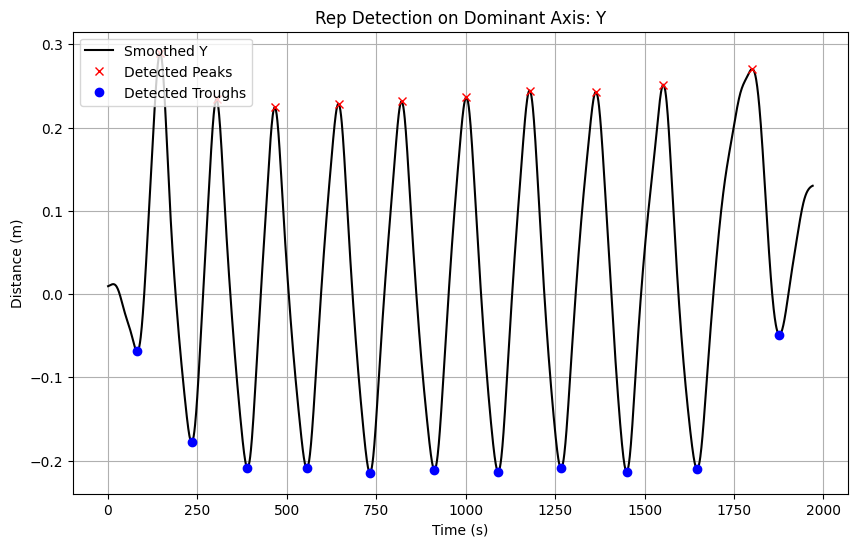

In [52]:
fs = 100  # Sampling frequency
cutoff = 3  # Cutoff frequency for smoothing

def filter(data):
    b, a = butter(1, 2 * cutoff / (fs), btype="highpass")
    return filtfilt(b, a, data)
    
# Process reps
t = np.concatenate(record['Counter'].to_numpy())
start_idx = int(start_predict * fs) 
end_idx = int(end_predict * fs) +120

#record = data[data['Exercise_id'] == exercise_id]
#record = record.sample(1)
#record = preprocess_data_rep_counting(record, config['CutoffFreq'], config['SampleRate'], start_idx, end_idx)

pos_x = np.concatenate(record['PosX'].to_numpy())[start_idx:end_idx]
pos_y = np.concatenate(record['PosY'].to_numpy())[start_idx:end_idx]
pos_z = np.concatenate(record['PosZ'].to_numpy())[start_idx:end_idx]

vel_x = np.concatenate(record['VelX'].to_numpy())[start_idx:end_idx]
vel_y = np.concatenate(record['VelY'].to_numpy())[start_idx:end_idx]
vel_z = np.concatenate(record['VelZ'].to_numpy())[start_idx:end_idx]

pitch = np.concatenate(record['Pitch'].to_numpy())[start_idx:end_idx]
roll = np.concatenate(record['Roll'].to_numpy())[start_idx:end_idx]
yaw = np.concatenate(record['Yaw'].to_numpy())[start_idx:end_idx]

# Process reps
#smooth_signal, peaks, troughs, reps, dominant_axis = process_reps(vel_x, vel_y, vel_z, fs=fs, cutoff=cutoff)
smooth_signal, peaks, troughs, reps, dominant_axis = process_reps(pos_x, pos_y, pos_z, pitch, roll, yaw, vel_x, vel_y, vel_z, fs=fs, cutoff=cutoff)

print(peaks)

# Ensure t and smooth_signal have the same length
t = t[:len(smooth_signal)]

plt.figure(figsize=(10, 6))

# Plot the smoothed signal and detected peaks/troughs.
plt.plot(t, smooth_signal, label=f"Smoothed {dominant_axis}", color='black')
plt.plot(t[peaks], smooth_signal[peaks], "x", label="Detected Peaks", color='red')
plt.plot(t[troughs], smooth_signal[troughs], "o", label="Detected Troughs", color='blue')

plt.title(f"Rep Detection on Dominant Axis: {dominant_axis}")
plt.xlabel("Time (s)")
plt.ylabel("Distance (m)")
plt.legend()
plt.grid()
plt.show()

#print(f"Detected Reps: {reps}")
#print(f"Number of Reps: {len(reps)}")
#print(f"Actual number of reps: {record['Reps'].values[0]}")
#rint("exercise type:", record['Exercise'].values[0])

measuring intensity

In [53]:
import numpy as np
from scipy.signal import butter, filtfilt

def compute_rep_metrics(pos_signal, vel_x, vel_y, vel_z, reps, pitch, roll, yaw, outlier_threshold=0.20):
    """
    Compute per-rep metrics including:
      - Peak velocity (magnitude of 3-axis velocity, computed as the maximum value over the rep window)
      - Range of motion (difference between max and min position)
      - Stability (average of the standard deviations of pitch, roll, and yaw)
    
    Additionally, computes:
      - Velocity loss (%): Loss in velocity between the rep with the highest and the rep with the lowest
        peak velocity, computed after excluding the first and last reps (if there are at least 3 reps).
      - Stability similarity (%): A measure of how similar the stability values are across reps.
        If every rep has the same stability, this value is 100%; if they vary widely, it approaches 0%.
    
    Parameters:
      pos_signal : np.array
          Position signal for the dominant (or chosen) axis.
      vel_x, vel_y, vel_z : np.array
          Velocity signals along each axis.
      reps : list of tuples
          Each tuple (start_index, end_index) represents a candidate rep.
      pitch, roll, yaw : np.array
          Euler angle arrays (assumed to be aligned with the position data).
      outlier_threshold : float (default=0.20)
          (Not used in this version, but kept for consistency.)
    
    Returns:
      rep_metrics : list of dicts
          Each dictionary contains:
            - "peak_velocity (m/s)"
            - "range_of_motion (m)"
            - "stability (rad^2)"
      velocity_loss : float
          Loss in velocity (in %) computed from the peak velocities, after excluding the first and last reps when possible.
      stability_similarity : float
          A percentage indicating how similar the stability values are across reps (100% means identical).
    """
    rep_metrics = []
    # Compute overall velocity magnitude.
    vel_mag = np.sqrt(vel_x**2 + vel_y**2 + vel_z**2)
    
    for rep in reps:
        start, end = rep
        # Ensure the indices are valid for all signals.
        if end < len(vel_mag) and end < len(pos_signal) and end < len(pitch):
            # Use peak velocity instead of average velocity.
            peak_vel = np.max(vel_mag[start:end+1])
            rom = np.max(pos_signal[start:end+1]) - np.min(pos_signal[start:end+1])
            
            # Compute standard deviation for Euler angles over the rep window.
            pitch_std = np.std(pitch[start:end+1])
            roll_std  = np.std(roll[start:end+1])
            yaw_std   = np.std(yaw[start:end+1])
            stability = np.mean([pitch_std, roll_std, yaw_std])
            
            rep_metrics.append({
                "peak_velocity (m/s)": peak_vel,
                "range_of_motion (m)": rom,
                "stability (rad^2)": stability
            })
    
    # Compute velocity loss excluding the first and last rep if possible.
    if rep_metrics:
        rep_peak_velocities = np.array([m["peak_velocity (m/s)"] for m in rep_metrics])
        if len(rep_peak_velocities) > 2:
            excluded_first_vel = rep_peak_velocities[0]
            excluded_last_vel = rep_peak_velocities[-1]
            filtered_velocities = rep_peak_velocities[1:-1]
            print("Excluding first rep peak velocity:", excluded_first_vel,
                  "and last rep peak velocity:", excluded_last_vel)
            highest_vel = np.max(filtered_velocities)
            lowest_vel = np.min(filtered_velocities)
            velocity_loss = ((highest_vel - lowest_vel) / highest_vel) * 100 if highest_vel != 0 else 0.0
        else:
            highest_vel = np.max(rep_peak_velocities)
            lowest_vel = np.min(rep_peak_velocities)
            velocity_loss = ((highest_vel - lowest_vel) / highest_vel) * 100 if highest_vel != 0 else 0.0
    else:
        velocity_loss = None

    # Compute stability similarity across all reps.
    if rep_metrics:
        stability_values = np.array([m["stability (rad^2)"] for m in rep_metrics])
        mean_stability = np.mean(stability_values)
        std_stability = np.std(stability_values)
        # Compute the coefficient of variation (CV)
        cv = std_stability / mean_stability if mean_stability != 0 else 0.0
        # Convert to similarity percentage (100% if CV=0, 0% if CV>=1)
        stability_similarity = max(0, 100 * (1 - cv))
    else:
        stability_similarity = None

    return rep_metrics, velocity_loss, stability_similarity

# ---------------------------
# HRV and Other Utility Functions
# ---------------------------
def compute_hr(record):
    """
    Compute Heart Rate metrics from the record.
    
    Returns a dictionary with:
      - HRV: the standard deviation of heart rate values.
      - HR Average: the average heart rate.
      - HR Peak: the maximum heart rate observed.
      
    Note: For more advanced HRV metrics, you may wish to use RR intervals.
    """
    hr = np.concatenate(record['HeartRate'].to_numpy())
    hr_std = np.std(hr)
    hr_avg = np.mean(hr)
    hr_peak = np.max(hr)
    hr_metrics = {"HRV": hr_std, "HR Average": hr_avg, "HR Peak": hr_peak}
    return hr_metrics

def compute_intensity_metrics(record, pos_signal, vel_x, vel_y, vel_z, reps, fs, pitch, roll, yaw):
    """
    Compute a suite of intensity metrics from the sensor data.
    
    Parameters:
      record : pd.DataFrame
          The preprocessed sensor data.
      pos_signal : np.array
          The position signal used for rep detection.
      vel_x, vel_y, vel_z : np.array
          Velocity signals.
      reps : list of tuples
          Candidate rep indices.
      fs : int
          Sampling frequency.
      pitch, roll, yaw : np.array
          Euler angle signals.
    
    Returns:
      metrics : dict
          Contains:
            - "rep_metrics": List of per-rep metrics dictionaries.
            - "velocity_loss (%)": Overall velocity loss percentage across reps (excluding first and last reps when possible).
            - "stability_similarity (%)": Similarity in stability across reps (100% means identical).
            - "range_of_motion_consistency (%)": Consistency in range of motion across reps (100% means identical).
            - "heart_rate": A dictionary with HRV and average heart rate.
            - "num_reps": Total number of detected reps.
    """
    rep_metrics, velocity_loss, stability_similarity = compute_rep_metrics(pos_signal, vel_x, vel_y, vel_z, reps, pitch, roll, yaw)
    hr_metrics = compute_hr(record)
    
    # Compute Range of Motion Consistency (%)
    if rep_metrics:
        rom_values = np.array([m["range_of_motion (m)"] for m in rep_metrics])
        mean_rom = np.mean(rom_values)
        std_rom = np.std(rom_values)
        cv_rom = std_rom / mean_rom if mean_rom != 0 else 0.0
        rom_consistency = max(0, 100 * (1 - cv_rom))
    else:
        rom_consistency = None

    metrics = {
        "rep_metrics": rep_metrics,
        "velocity_loss (%)": velocity_loss,
        "stability_similarity (%)": stability_similarity,
        "range_of_motion_consistency (%)": rom_consistency,
        "heart_rate": hr_metrics,
        "num_reps": len(reps)
    }
    return metrics

In [54]:
# Compute overall intensity metrics (including heart rate metrics and average range of motion)
metrics = compute_intensity_metrics(record, smooth_signal, vel_x, vel_y, vel_z, reps, fs, pitch, roll, yaw)

print("Intensity Metrics:")
print(f"  Rep Metrics: {metrics['rep_metrics']}")
print(f"  Velocity Loss (%): {metrics['velocity_loss (%)']}")
print(f"  Technique Consistency (%): {metrics['stability_similarity (%)']}")
print(f"  Range of Motion Consistency (%): {metrics['range_of_motion_consistency (%)']}")
print(f"  Heart Rate Metrics: {metrics['heart_rate']}")
print(f"  Number of Reps: {metrics['num_reps']}")


Excluding first rep peak velocity: 0.8345399159721969 and last rep peak velocity: 0.5683515078327167
Intensity Metrics:
  Rep Metrics: [{'peak_velocity (m/s)': 0.8345399159721969, 'range_of_motion (m)': 0.3587219833806073, 'stability (rad^2)': 0.04202035874752199}, {'peak_velocity (m/s)': 0.8364169064726618, 'range_of_motion (m)': 0.4117108673256438, 'stability (rad^2)': 0.048932344709446934}, {'peak_velocity (m/s)': 0.7864074400653556, 'range_of_motion (m)': 0.4327763577087894, 'stability (rad^2)': 0.056245283951527135}, {'peak_velocity (m/s)': 0.7291950988606758, 'range_of_motion (m)': 0.43762857443458636, 'stability (rad^2)': 0.04784240487071004}, {'peak_velocity (m/s)': 0.6897951551015906, 'range_of_motion (m)': 0.4458371682131653, 'stability (rad^2)': 0.05321300249037627}, {'peak_velocity (m/s)': 0.7246864403526241, 'range_of_motion (m)': 0.447246307595073, 'stability (rad^2)': 0.045333355648779154}, {'peak_velocity (m/s)': 0.7430416161669451, 'range_of_motion (m)': 0.457615448643

In [55]:
from scipy.interpolate import CubicSpline


def smooth_reconstruction_from_keypoints(inflection_points, total_length):
    """
    Reconstruct a smooth signal using cubic spline interpolation from key inflection points.
    
    Args:
        inflection_points (list of tuple): List of (index, value) pairs representing key inflection points.
        total_length (int): The total number of points in the original time series.
    
    Returns:
        numpy.array: The reconstructed smooth signal evaluated at each index from 0 to total_length - 1.
    """
    # Sort the key points by their index
    inflection_points = sorted(inflection_points, key=lambda x: x[0])
    
    # Separate indices and values
    indices, values = zip(*inflection_points)
    indices = list(indices)
    values = list(values)
    
    # Ensure endpoints are included
    if indices[0] != 0:
        indices.insert(0, 0)
        values.insert(0, values[0])  # Option: use the first key point's value
    if indices[-1] != total_length - 1:
        indices.append(total_length - 1)
        values.append(values[-1])    # Option: use the last key point's value
    
    # Create a cubic spline interpolator
    cs = CubicSpline(indices, values, bc_type='natural')
    
    # Evaluate the spline over the entire range of the original series
    x = np.arange(total_length)
    smoothed_signal = cs(x)
    return smoothed_signal

def downsample_list(values, factor=10):
    """
    Downsamples a list or NumPy array by taking every 'factor'-th element.
    """
    return values[::factor]

def extract_inflection_points(series):
    """
    Extract key inflection points from a signal. Inflection points are identified
    where the first difference changes sign (i.e. a local minimum or maximum).
    
    Returns a list of tuples (index, value) for the downsampled signal.
    """
    inflections = []
    for i in range(1, len(series) - 1):
        prev_diff = series[i] - series[i - 1]
        next_diff = series[i + 1] - series[i]
        if prev_diff * next_diff < 0:
            inflections.append((i, series[i]))
    return inflections

def process_signals(signals, factor=10):
    """
    Processes multiple signals by downsampling each and extracting their inflection points.
    
    Stores the results in a dictionary where each key is a signal name and the value 
    is a dictionary containing:
      - 'inflections': list of (index, value) tuples for the downsampled signal
      - 'original_length': the length of the original signal
      - 'downsampling_factor': the factor used for downsampling
    """
    results = {}
    for name, signal in signals.items():
        original_length = len(signal)
        downsampled_signal = downsample_list(signal, factor)
        inflection_points = extract_inflection_points(downsampled_signal)
        results[name] = {
            'inflections': inflection_points,
            'original_length': original_length,
            'downsampling_factor': factor
        }
    return results


In [415]:
signals = {
    'pos_x': pos_x,
    'pos_y': pos_y,
    'pos_z': pos_z,
    'vel_x': vel_x,
    'vel_y': vel_y,
    'vel_z': vel_z,
}
results = process_signals(signals, factor=10)
for name, data in results.items():
    print(f"Signal: {name}")
    print("Inflection points length:", len(data['inflections']))
    print("downsample factor:", data['downsampling_factor'])
    print("Original length:", data['original_length'])


Signal: pos_x
Inflection points length: 21
downsample factor: 10
Original length: 2020
Signal: pos_y
Inflection points length: 22
downsample factor: 10
Original length: 2020
Signal: pos_z
Inflection points length: 38
downsample factor: 10
Original length: 2020
Signal: vel_x
Inflection points length: 44
downsample factor: 10
Original length: 2020
Signal: vel_y
Inflection points length: 49
downsample factor: 10
Original length: 2020
Signal: vel_z
Inflection points length: 61
downsample factor: 10
Original length: 2020


In [56]:
# Reconstructing vel_x:
velx_data = results['vel_x']
factor = velx_data['downsampling_factor']
original_length = velx_data['original_length']
inflections_downsampled = velx_data['inflections']

# Scale the inflection indices to match the original signal's index scale.
inflections_original = [(idx * factor, value) for idx, value in inflections_downsampled]

# Use the smooth reconstruction function on the scaled key points.
reconstructed_velx = smooth_reconstruction_from_keypoints(inflections_original, total_length=original_length)

# Optionally, plot the reconstructed signal along with its key inflection points.
x = np.arange(original_length)
plt.figure(figsize=(10, 6))
plt.plot(x, reconstructed_velx, label="Reconstructed vel_x", linestyle="--")
# Plot the key inflection points (scaled to original indices)
key_indices, key_values = zip(*inflections_original)
plt.scatter(key_indices, key_values, color="red", label="Key Inflection Points")
plt.xlabel("Index")
plt.ylabel("vel_x Value")
plt.title("Smooth Reconstruction of vel_x from Key Inflection Points")
plt.legend()
plt.show()


NameError: name 'results' is not defined

In [523]:
print ("intensity actual:", record['Intensity'].values[0])

intensity actual: 9.0


## Calculate start time predictions for all data

### Calculate error for each record

In [42]:
start_errors = []
end_errors = []

rep_predictions = []
rep_actuals = []
record_UUID = []
all_metrics = []  # New list for intensity metrics
actual_intensity = []
exercise = []

data = preprocess_data(data, config['CutoffFreq'], config['SampleRate'])
for i in range(len(data)):
    try:
        record = data.loc[[i]]
        window_features = extract_window_features(record, config['WindowLength'], config['WindowStride'])
        predictions = window_classifier.predict(window_features)

        start_predict_index, end_predict_index = predict_exercise_indices(
            predictions, config['WindowLength'], config['WindowStride'], config['MinConsqWindows'])
        
        start_predict = start_predict_index / config['SampleRate']
        end_predict = end_predict_index / config['SampleRate']

        start_actual = float(record['StartRepTime'].values[0])
        end_actual = float(record['EndRepTime'].values[0])
        
        start_error = abs(start_predict - start_actual)
        end_error = abs(end_predict - end_actual)
        start_errors.append(start_error)
        end_errors.append(end_error)
        
        fs = 100  # Sampling frequency
        cutoff = 3  # Cutoff frequency for smoothing

        start_idx = int(start_predict * fs)
        end_idx = int(end_predict * fs) + 100

        #record = record.sample(1)
        #record = preprocess_data_rep_counting(record, config['CutoffFreq'], config['SampleRate'], start_idx, end_idx)

        pos_x = np.concatenate(record['PosX'].to_numpy())[start_idx:end_idx]
        pos_y = np.concatenate(record['PosY'].to_numpy())[start_idx:end_idx]
        pos_z = np.concatenate(record['PosZ'].to_numpy())[start_idx:end_idx]

        vel_x = np.concatenate(record['VelX'].to_numpy())[start_idx:end_idx]
        vel_y = np.concatenate(record['VelY'].to_numpy())[start_idx:end_idx]
        vel_z = np.concatenate(record['VelZ'].to_numpy())[start_idx:end_idx]
        
        # Extract Euler angles for stability metrics.
        pitch = np.concatenate(record['Pitch'].to_numpy())[start_idx:end_idx]
        roll = np.concatenate(record['Roll'].to_numpy())[start_idx:end_idx]
        yaw = np.concatenate(record['Yaw'].to_numpy())[start_idx:end_idx]

        smooth_signal, peaks, troughs, reps, dominant_axis = process_reps(pos_x, pos_y, pos_z, fs=fs, cutoff=cutoff)
        
        # Compute intensity metrics (this function returns a dictionary of metrics).
        metrics = compute_intensity_metrics(record, smooth_signal, vel_x, vel_y, vel_z, reps, fs, exercise_type, pitch, roll, yaw)

        rep_predictions.append(len(reps))
        rep_actuals.append(record['Reps'].values[0])
        record_UUID.append(record['Exercise_id'].values[0])
        actual_intensity.append(record['Intensity'].values[0])
        exercise.append(record['Exercise'].values[0])
        all_metrics.append(metrics)  # Save the metrics for this record

    except Exception as e:
        print(f"Error processing record {i}: {e}")
        continue

# Convert lists to arrays for consistency.
start_errors = np.array(start_errors)
end_errors = np.array(end_errors)
rep_predictions = np.array(rep_predictions)
rep_actuals = np.array(rep_actuals)
record_UUID = np.array(record_UUID)
all_metrics = np.array(all_metrics)
actual_intensity = np.array(actual_intensity)
exercise = np.array(exercise)


Dominant Axis: X, Variances: {'X': 0.012949120639924983, 'Y': 0.0005696140554362339, 'Z': 0.0015809769634268606}
Rep 1: Amp=0.33 (median=0.33), Dur=1.20 (median=0.92)
Rep 2: Amp=0.31 (median=0.33), Dur=0.98 (median=0.92)
Rep 3: Amp=0.32 (median=0.33), Dur=0.92 (median=0.92)
Rep 4: Amp=0.32 (median=0.33), Dur=0.96 (median=0.92)
Rep 5: Amp=0.32 (median=0.33), Dur=0.92 (median=0.92)
Rep 6: Amp=0.34 (median=0.33), Dur=0.91 (median=0.92)
Rep 7: Amp=0.32 (median=0.33), Dur=0.88 (median=0.92)
Rep 8: Amp=0.34 (median=0.33), Dur=0.88 (median=0.92)
Rep 9: Amp=0.33 (median=0.33), Dur=0.81 (median=0.92)
Rep 10: Amp=0.34 (median=0.33), Dur=0.83 (median=0.92)
Rep 11: Amp=0.33 (median=0.33), Dur=1.02 (median=0.92)
Rep 12: Amp=0.34 (median=0.33), Dur=1.00 (median=0.92)
Rep 13: Amp=0.41 (median=0.33), Dur=1.41 (median=0.92)
Valid reps: [(134, 254), (335, 433), (523, 615), (709, 805), (900, 992), (1090, 1181), (1277, 1365), (1471, 1559), (1662, 1743), (1851, 1934), (2052, 2154), (2301, 2401), (2529, 267

KeyboardInterrupt: 

In [167]:
print("rep predictions", rep_predictions)
print("rep actuals", rep_actuals)


rep predictions [13, 8, 6, 4, 8, 9, 8, 10, 10, 11, 7, 10, 9, 8, 8, 8, 11, 10, 13, 11, 11, 11, 11, 13, 14, 14, 10, 11, 11, 12, 9, 9, 10, 14, 9, 8, 8, 12, 9, 8, 8, 11, 12, 9, 10, 11, 10, 8, 6, 6, 5, 10, 7, 8, 8, 8, 11, 11, 10, 10, 8, 8, 12, 12, 9, 8, 8, 5, 9, 11, 11, 11, 13, 11, 11, 6, 11, 8, 7, 7, 16, 15, 8, 7, 7, 8, 7, 10, 11, 9, 7, 9, 10, 10, 7, 7, 8, 8, 4, 5, 5, 14, 11, 8, 6, 8, 8, 11, 12, 16, 14, 8, 5, 7, 7, 7, 4, 2, 3, 9, 8, 15, 7, 7, 6, 7, 8, 5, 5, 11, 9, 5, 5, 7, 5, 6, 9, 11, 10, 12, 8, 10, 10, 9, 11, 11, 11, 10, 10, 10, 10, 5, 6, 5, 5, 10, 9, 7, 8, 3, 3, 3, 7, 10, 7, 7, 10, 10, 10, 11, 9, 6, 8, 8, 6, 7, 4, 9, 10, 6, 7, 7, 11, 12, 11, 11, 11, 7, 7, 5, 3, 9, 10, 9, 7, 7, 10, 8, 10, 5, 6, 4, 8, 10, 7, 8, 7, 6, 8, 7, 7, 5, 3, 2, 6, 8, 11, 9, 7, 10, 9, 6, 6, 7, 8, 10, 9, 9, 8, 11, 11, 11, 9, 9, 10, 10, 10, 11, 9, 11, 11, 10, 10, 10, 6, 8, 11, 7, 6, 8, 11, 9, 9, 8, 10, 10, 8, 12, 14, 6, 6, 3, 5, 7, 7, 6, 5, 4, 6, 8, 9, 11, 11, 8, 8, 8, 9, 9, 9, 8, 7, 8, 10, 8, 10, 11, 8, 7, 10, 9, 4, 

In [526]:
# Ensure all arrays have the same length
if not (len(rep_predictions) == len(rep_actuals) == len(record_UUID)):
    raise ValueError("All input arrays must have the same length.")

metrics_df = pd.json_normalize(all_metrics)
# Create a DataFrame with each array as a column
df = pd.DataFrame({
    'rep_predictions': rep_predictions,
    'rep_actuals': rep_actuals,
    'record_UUID': record_UUID,
    'actual_intensity': actual_intensity,
    'velocity loss': metrics_df['velocity_loss (%)'],
    'stability variance': metrics_df['stability_variance'],
    'HRV': metrics_df['heart_rate.HRV'],
    'HR Average': metrics_df['heart_rate.HR Average'],
    'exercise': exercise
    
})

# Write the DataFrame to an Excel file
df.to_excel('output.xlsx', index=False)


In [ ]:
start_errors = []
end_errors = []

data = preprocess_data(data, config['CutoffFreq'], config['SampleRate'])
for i in range(len(data)):
    record = data.loc[[i]]
    window_features = extract_window_features(record, config['WindowLength'], config['WindowStride'])
    predictions = window_classifier.predict(window_features)

    start_predict_index, end_predict_index = predict_exercise_indices(
        predictions, config['WindowLength'], config['WindowStride'], config['MinConsqWindows'])
    
    start_predict = start_predict_index / config['SampleRate']
    end_predict = end_predict_index / config['SampleRate']

    start_actual = float(record['StartRepTime'].values[0])
    end_actual = float(record['EndRepTime'].values[0])
    
    

start_errors = np.array(start_errors)
end_errors = np.array(end_errors)

### Log the results

In [ ]:
start_avg_error = np.mean(start_errors)
end_avg_error = np.mean(end_errors)

print(f"Average start error: {start_avg_error:.3f}")
print(f"Average end error: {end_avg_error:.3f}")

RESULTS_FOLDER = 'results'
RESULTS_FILENAME = 'results.txt'

from datetime import datetime
import os

results_file = path.join(RESULTS_FOLDER, RESULTS_FILENAME)

if not path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)

with open(results_file, 'a') as f:
    f.write(f"{datetime.now()}\n")
    f.write(f"Average start error: {start_avg_error:.3f}\n")
    f.write(f"Average end error: {end_avg_error:.3f}\n")
    f.write(f"Window length: {config['WindowLength']}\n")
    f.write(f"Window stride: {config['WindowStride']}\n")
    f.write(f"Min consecutive windows: {config['MinConsqWindows']}\n\n")

### Save this notebook to a script

In [ ]:
# Convert the notebook to a script
!jupyter nbconvert --to script BarPathModelTraining.ipynb --output test_models